In [160]:
import pandas as pd
import numpy as np

# -- Visualization --
import seaborn as sns
import matplotlib.pyplot as plt

# -- RDKit --
from rdkit import Chem
from rdkit.Chem import Draw, rdMolDescriptors, Lipinski, Descriptors, Crippen
from rdkit import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

pd.set_option('display.max_columns', None)

In [231]:
df = pd.read_csv(r'..\data\delaney.csv')

In [232]:
df.head(2)

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl


In [233]:
df.isna().sum()

Compound ID                             0
measured log(solubility:mol/L)          0
ESOL predicted log(solubility:mol/L)    0
SMILES                                  0
dtype: int64

In [234]:
df.columns

Index(['Compound ID', 'measured log(solubility:mol/L)',
       'ESOL predicted log(solubility:mol/L)', 'SMILES'],
      dtype='object')

In [235]:
df.shape

(1144, 4)

In [236]:
target_columns = ['Compound ID', 'measured log(solubility:mol/L)', 'ESOL predicted log(solubility:mol/L)', 'SMILES']

summary = pd.DataFrame({
    "null_count": df[target_columns].isna().sum(),
    "non_null_count": df[target_columns].notna().sum(),
    "null_%": (df[target_columns].isna().mean() * 100).round(2),

}).sort_values("null_count", ascending=False)

summary

,null_count,non_null_count,null_%
Compound ID,0,1144,0.0
measured log(solubility:mol/L),0,1144,0.0
ESOL predicted log(solubility:mol/L),0,1144,0.0
SMILES,0,1144,0.0


In [237]:
def get_aromatic_proportion(mol):
    aromatic_atoms = sum([1 for atom in mol.GetAtoms() if atom.GetIsAromatic()])
    heavy_atoms = Descriptors.HeavyAtomCount(mol)
    return aromatic_atoms / heavy_atoms if heavy_atoms > 0 else 0

def calculate_descriptors_safe(smiles):
    """
    Calculates multiple molecular descriptors from a SMILES string.
    Returns a pandas Series so it can add multiple columns at once.
    Output schema is IDENTICAL to the original function.
    """
    morgan_gen = GetMorganGenerator(radius=3, fpSize=2048)
    try:
        # 1. Safely create and sanitize molecule
        mol = Chem.MolFromSmiles(smiles, sanitize=True)
        if mol is None:
            raise ValueError("Invalid SMILES")

        # 2. Remove explicit hydrogens (fixes H-without-neighbors warning)
        mol = Chem.RemoveHs(mol)

        # 3. Calculate descriptors (same as before)
        return pd.Series({
            'tpsa': rdMolDescriptors.CalcTPSA(mol),
            'mw':   Descriptors.MolWt(mol),
            'hbd':  Descriptors.NumHDonors(mol),
            'hba':  Descriptors.NumHAcceptors(mol),
            'rot':  Descriptors.NumRotatableBonds(mol),
            'logp': Crippen.MolLogP(mol),
            # 'mr':   Crippen.MolMR(mol),
            # 'hac':  Lipinski.HeavyAtomCount(mol),
            # 'fp':   morgan_gen.GetFingerprint(mol),  # 🔥 NO deprecation warning
            'aromatic_proportion': get_aromatic_proportion(mol)
        })

    except Exception:
        # 4. Fail safely (same NaN structure as original)
        return pd.Series({
            'tpsa': np.nan,
            'mw': np.nan,
            'hbd': np.nan,
            'hba': np.nan,
            'rot': np.nan,
            'logp': np.nan,
            # 'mr': np.nan,
            # 'hac': np.nan,
            # 'fp': np.nan,
            'aromatic_proportion': np.nan
        })

# Apply the function (Creating all columns in one go)
# This returns a new DataFrame with the descriptor columns
descriptor_cols = df['SMILES'].apply(calculate_descriptors_safe)

# Join these new columns back to your original DataFrame
df = pd.concat([df, descriptor_cols], axis=1)

# Check for failures (just checking one column is enough since they all fail together)
print(f"Failed rows: {df['tpsa'].isna().sum()}")

Failed rows: 0


In [238]:
df.head(2)

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,tpsa,mw,hbd,hba,rot,logp,aromatic_proportion
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,0.0,167.850,0.0,0.0,0.0,2.5954,0.0
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,0.0,133.405,0.0,0.0,0.0,2.3765,0.0


In [239]:
# def to_array(fp):
#     arr = np.zeros(fp.GetNumBits(), dtype=np.uint8)
#     DataStructs.ConvertToNumpyArray(fp, arr)
#     return arr
# fp_array = df['fp'].apply(to_array)

# df['fp'] = fp_array

In [240]:
df.columns

Index(['Compound ID', 'measured log(solubility:mol/L)',
       'ESOL predicted log(solubility:mol/L)', 'SMILES', 'tpsa', 'mw', 'hbd',
       'hba', 'rot', 'logp', 'aromatic_proportion'],
      dtype='object')

In [243]:
cols = ['tpsa', 'mw', 'hbd', 'hba', 'rot', 'logp', 'aromatic_proportion']

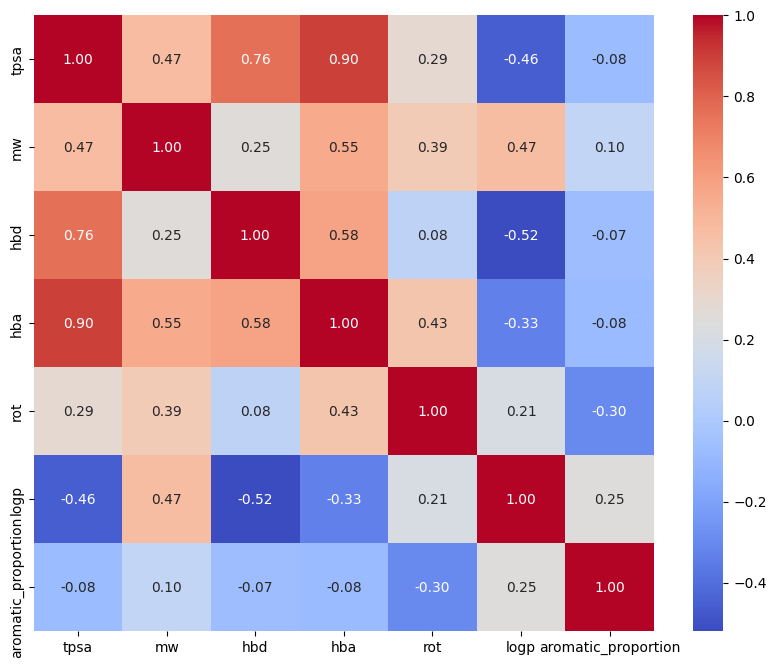

In [244]:
corr_matrix = df[cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [245]:
df.columns

Index(['Compound ID', 'measured log(solubility:mol/L)',
       'ESOL predicted log(solubility:mol/L)', 'SMILES', 'tpsa', 'mw', 'hbd',
       'hba', 'rot', 'logp', 'aromatic_proportion'],
      dtype='object')

In [246]:
scalor = ['mw', 'hbd', 'hba', 'rot', 'logp', 'aromatic_proportion']
# X = np.hstack([df[scalor], np.stack(df['fp'])])
X = df[scalor]
y = df['measured log(solubility:mol/L)']

In [247]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [248]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [254]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')
print(f'R2 Score: {r2}')


Mean Absolute Error: 0.47807046937366376
R2 Score: 0.8979540084882672


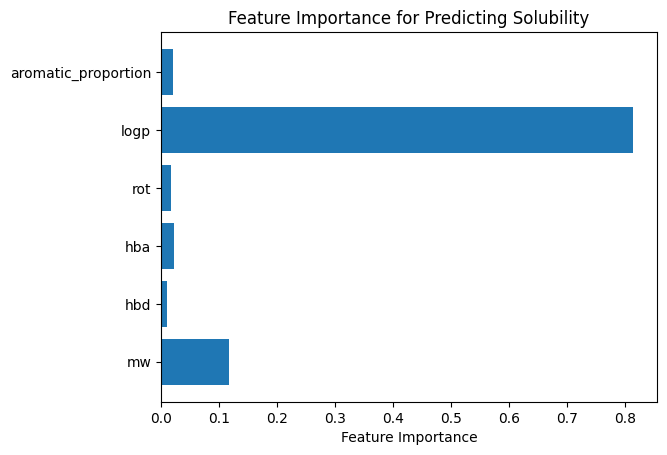

In [255]:
# Feature importance from Random Forest
importances = model.feature_importances_
feature_names = X.columns

# Create a bar plot of feature importance
plt.barh(feature_names, importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance for Predicting Solubility')
plt.show()

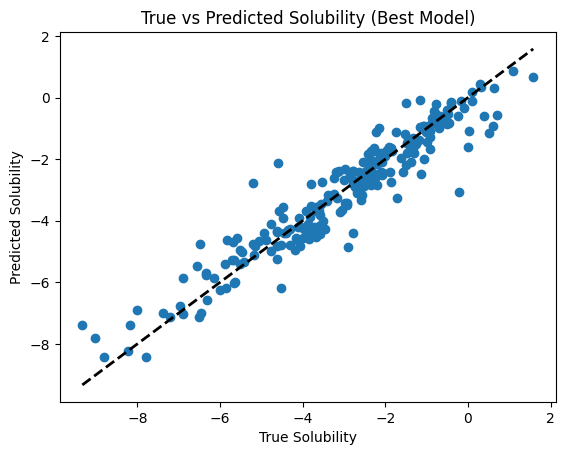

In [256]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('True Solubility')
plt.ylabel('Predicted Solubility')
plt.title('True vs Predicted Solubility (Best Model)')
plt.show()

In [258]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Features and target
X = df[scalor]  # Features
y = df['measured log(solubility:mol/L)']  # Target variable

# Initialize Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Set up cross-validation (e.g., 5-fold cross-validation)
cv = KFold(n_splits=5, random_state=42, shuffle=True)

# Perform cross-validation and get the scores (e.g., R² for regression)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='r2')

# Print cross-validation results
print("Cross-validation R² scores:", cv_scores)
print("Mean R² score:", np.mean(cv_scores))
print("Standard Deviation of R² scores:", np.std(cv_scores))

Cross-validation R² scores: [0.89803609 0.88597472 0.88037268 0.8710003  0.87840662]
Mean R² score: 0.8827580790340168
Standard Deviation of R² scores: 0.009018149303918362


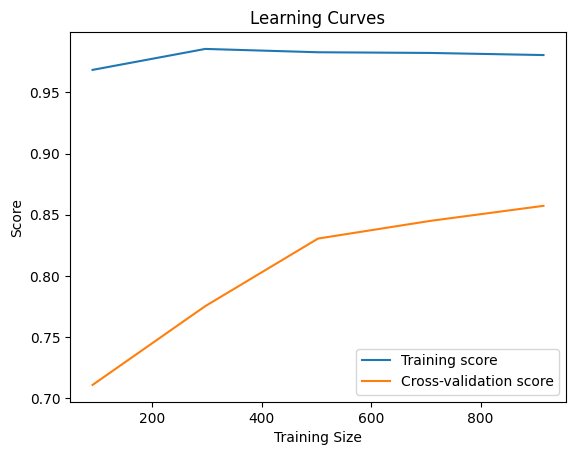

In [259]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(model, X, y, cv=5)

plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training score')
plt.plot(train_sizes, np.mean(val_scores, axis=1), label='Cross-validation score')
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.legend()
plt.title('Learning Curves')
plt.show()


In [260]:
#loading new set of data to predict solubility of unknwon molecules using the model we build
sol1 = pd.read_csv('https://raw.githubusercontent.com/Rajnishphe/AIDD-2022/main/ML%20Based%20QSAR/new_1.csv')

In [262]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

# Define a function to calculate aromatic proportion
def get_aromatic_proportion(mol):
    aromatic_atoms = sum([1 for atom in mol.GetAtoms() if atom.GetIsAromatic()])
    heavy_atoms = Descriptors.HeavyAtomCount(mol)
    return aromatic_atoms / heavy_atoms if heavy_atoms > 0 else 0

# Initialize empty lists for each descriptor
mol_wt = []
logp = []
num_rot_bonds = []
num_h_donors = []
num_h_acceptors = []
aromatic_proportion = []
tpsa = []  # List to store TPSA values

# Calculate descriptors
for smiles in sol1['SMILES']:  # Loop through the SMILES column in your sol1 DataFrame
    mol = Chem.MolFromSmiles(smiles)

    if mol is not None:
        mol_wt.append(Descriptors.MolWt(mol))
        logp.append(Descriptors.MolLogP(mol))
        num_rot_bonds.append(Descriptors.NumRotatableBonds(mol))
        num_h_donors.append(Descriptors.NumHDonors(mol))  # Corrected here
        num_h_acceptors.append(Descriptors.NumHAcceptors(mol))
        aromatic_proportion.append(get_aromatic_proportion(mol))
        tpsa.append(Descriptors.TPSA(mol))  # Add TPSA calculation here
    else:
        mol_wt.append(None)
        logp.append(None)
        num_rot_bonds.append(None)
        num_h_donors.append(None)
        num_h_acceptors.append(None)
        aromatic_proportion.append(None)
        tpsa.append(None)  # Handle None case for TPSA

# Add descriptors to the dataframe
sol1['MolWt'] = mol_wt
sol1['LogP'] = logp
sol1['NumRotatableBonds'] = num_rot_bonds
sol1['NumHDonors'] = num_h_donors
sol1['NumHAcceptors'] = num_h_acceptors
sol1['AromaticProportion'] = aromatic_proportion
sol1['TPSA'] = tpsa  # Add TPSA to the DataFrame

# Save the updated DataFrame to a new CSV file
sol1.to_csv('updated_sol1.csv', index=False)

# Display the updated dataframe
sol1.head(2)



,Ambit_InchiKey,score,activity,SMILES,MolWt,LogP,NumRotatableBonds,NumHDonors,NumHAcceptors,AromaticProportion,TPSA
0,PFNFFQXMRSDOHW-UHFFFAOYNA-N,1,Active,N(CCCCNCCCN)CCCN,202.346,-0.3566,11,4,4,0.000000,76.10
1,HOTSFPXUILMJMT-UHFFFAOYNA-N,1,Active,OC(CNC=1C=CC=CC1)COC,181.235,1.1058,5,2,3,0.461538,41.49


In [263]:
X_sol1 = sol1[['MolWt', 'LogP', 'NumRotatableBonds', 'NumHDonors', 'NumHAcceptors', 'AromaticProportion']]
X_sol1_scaled = scaler.transform(X_sol1)

predicted_solubility = model.predict(X_sol1_scaled)
sol1['Predicted_Solubility'] = predicted_solubility

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- AromaticProportion
- LogP
- MolWt
- NumHAcceptors
- NumHDonors
- ...
Feature names seen at fit time, yet now missing:
- aromatic_proportion
- hba
- hbd
- logp
- mw
- ...
